In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
dataset = pd.read_csv("indian_roads_dataset.csv")

In [4]:
dataset

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


### Let's inspect Head, Shape, Dtypes and Missing values

In [6]:
dataset.shape


(20000, 24)

In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  str    
 2   state              20000 non-null  str    
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  str    
 6   time               20000 non-null  str    
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  str    
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  str    
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  str    
 14  visibility         20000 non-null  str    
 15  temperature        20000 non-null  int64  
 16  traffic_density    20000 non-null

In [10]:
dataset.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

### Festival has mostly none values as most days are not festivals expected

In [16]:
dataset['is_festival'] = dataset['festival'].notnull().astype(int)

In [18]:
dataset["is_festival"].value_counts()

is_festival
0    19885
1      115
Name: count, dtype: int64

### Now Does Accident's Increase During Festivals.?

In [23]:
dataset.groupby("festival")["accident_id"].count()

festival
Diwali      31
Eid         34
Holi        38
New Year    12
Name: accident_id, dtype: int64

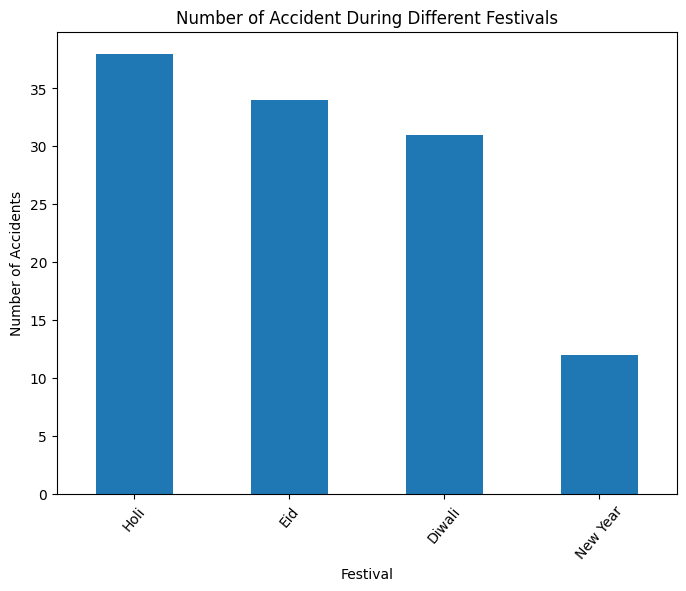

In [24]:
festival_counts = dataset["festival"].value_counts()

plt.figure(figsize=(8,6))
festival_counts.plot(kind='bar')

plt.title("Number of Accident During Different Festivals")
plt.xlabel("Festival")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=50)
plt.show()

In [26]:
dataset["festival_clean"] = dataset["festival"].fillna("No Festival")

In [28]:
dataset["festival_clean"].value_counts()

festival_clean
No Festival    19885
Holi              38
Eid               34
Diwali            31
New Year          12
Name: count, dtype: int64

In [30]:
festival_risk = dataset.groupby("festival_clean")["risk_score"].mean().sort_values()

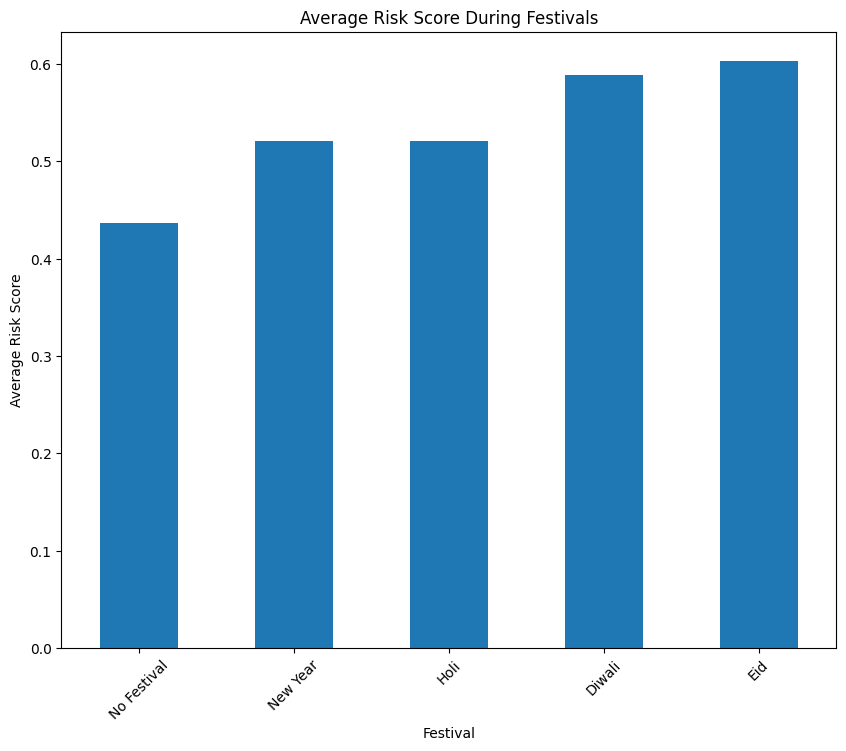

In [32]:
plt.figure(figsize=(10,8))
festival_risk.plot(kind="bar")

plt.title("Average Risk Score During Festivals")
plt.xlabel("Festival")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)
plt.show()

### Univariate Analysis (Feature by Feature)

1. Numerical Features
2. Categorical Features
3. Binary Features

In [33]:
num_cols = dataset.select_dtypes(include=["int64", "float64"]).columns

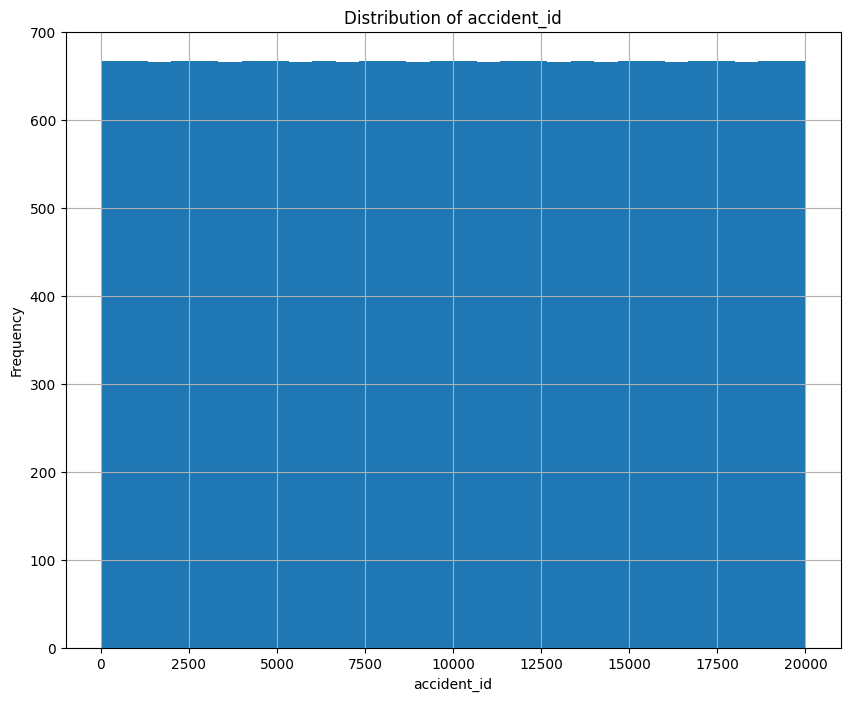

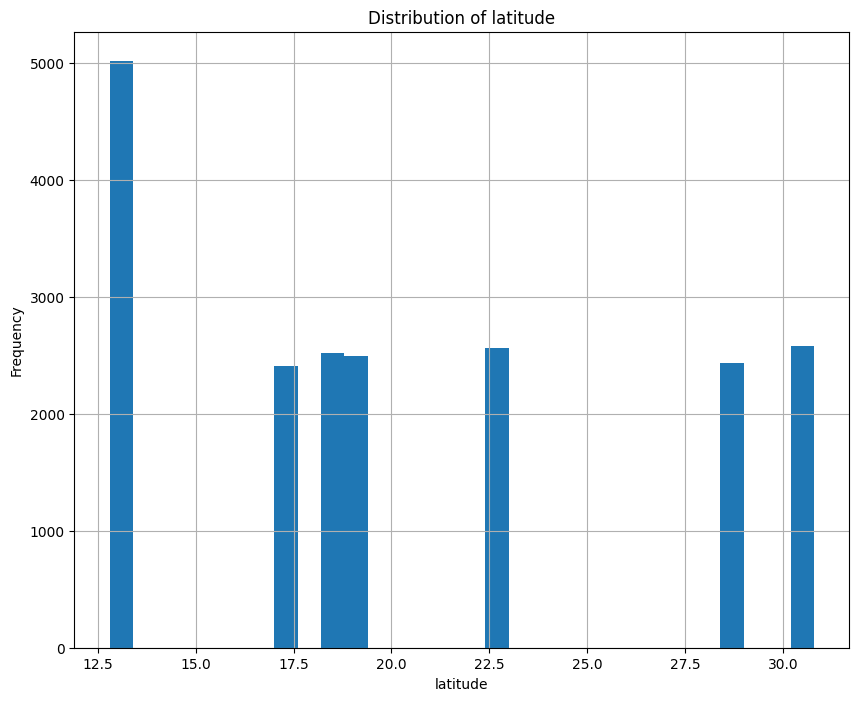

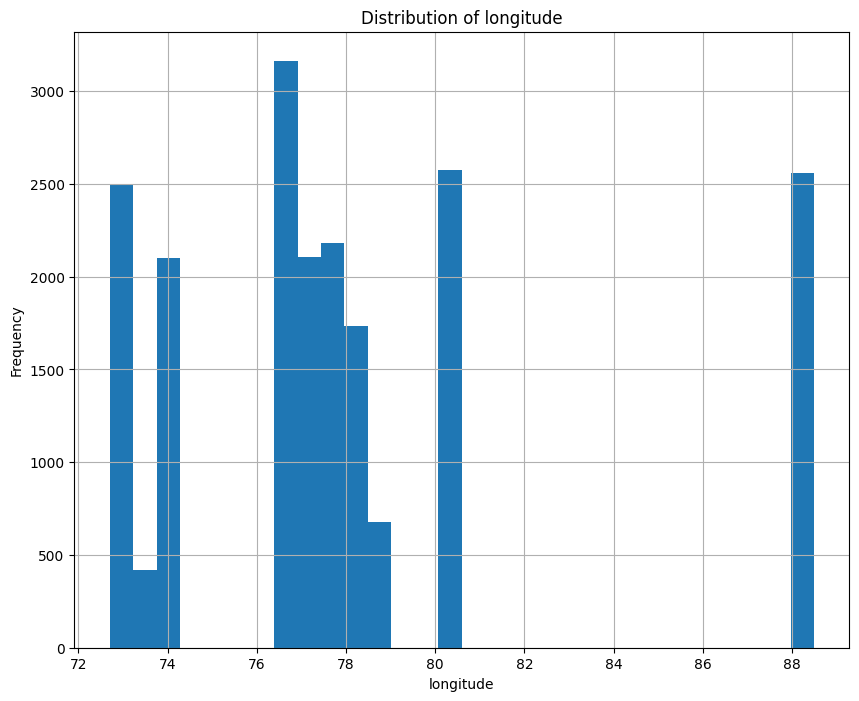

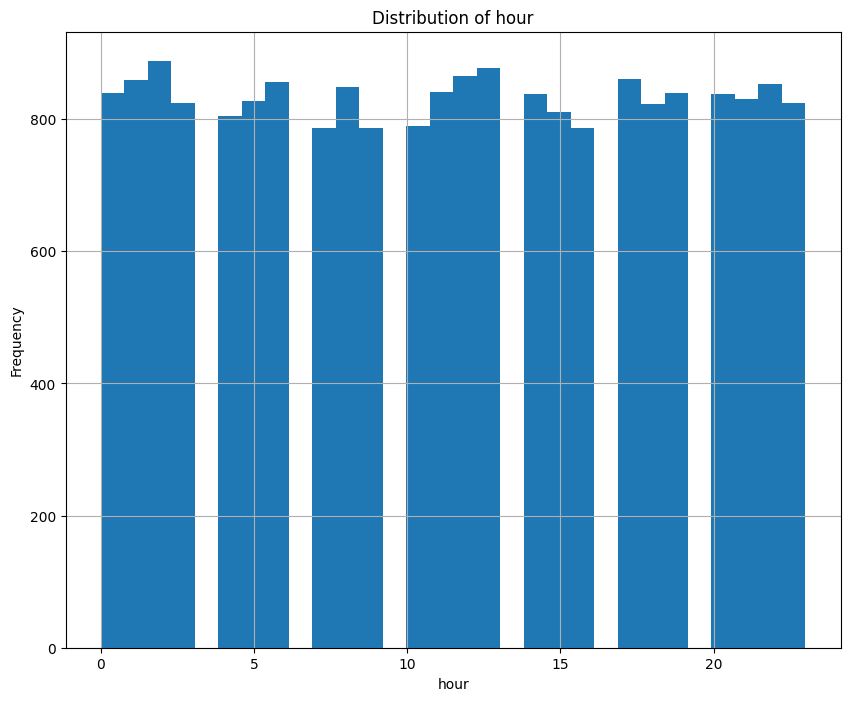

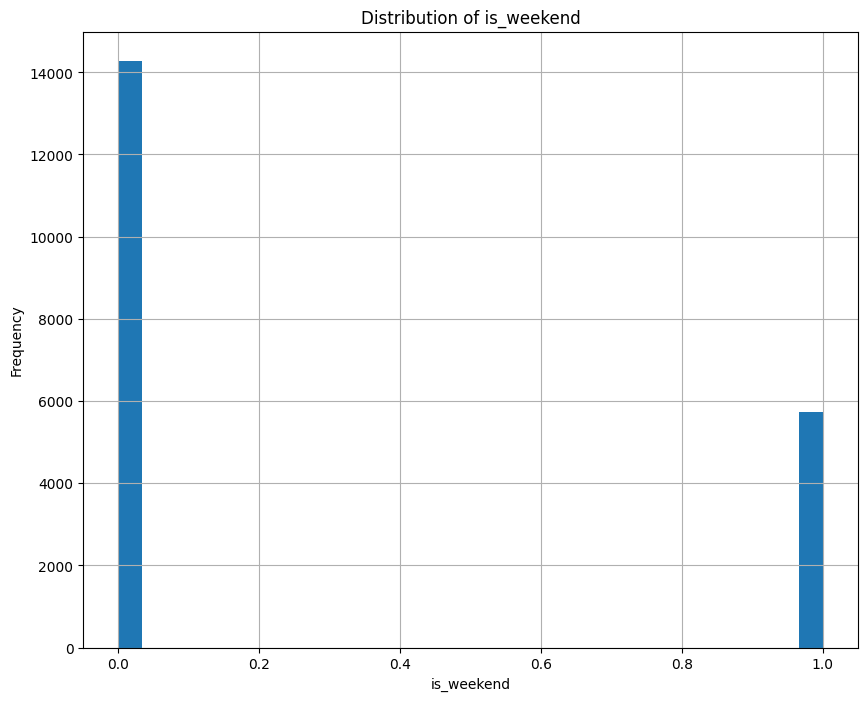

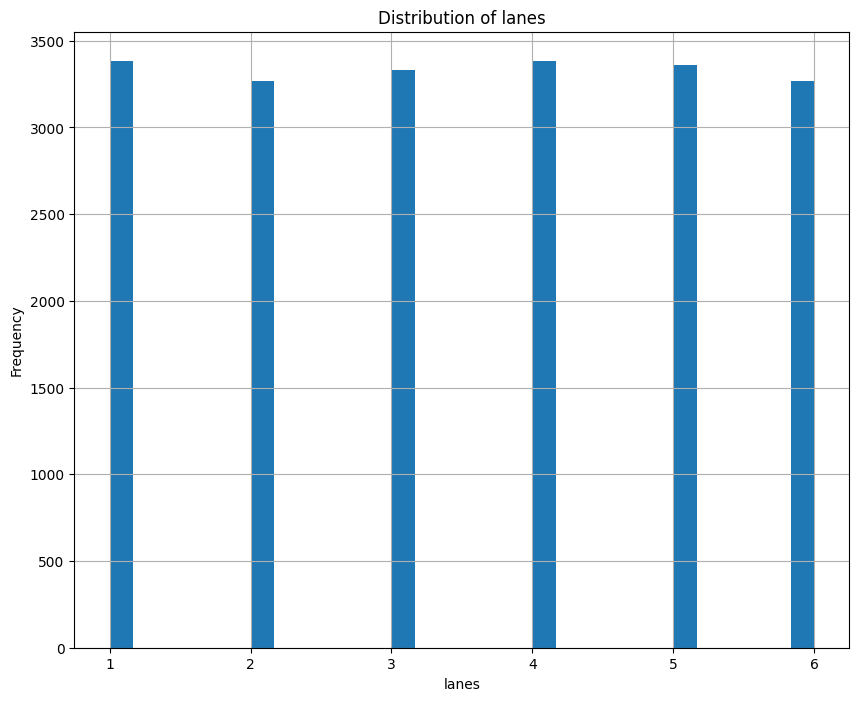

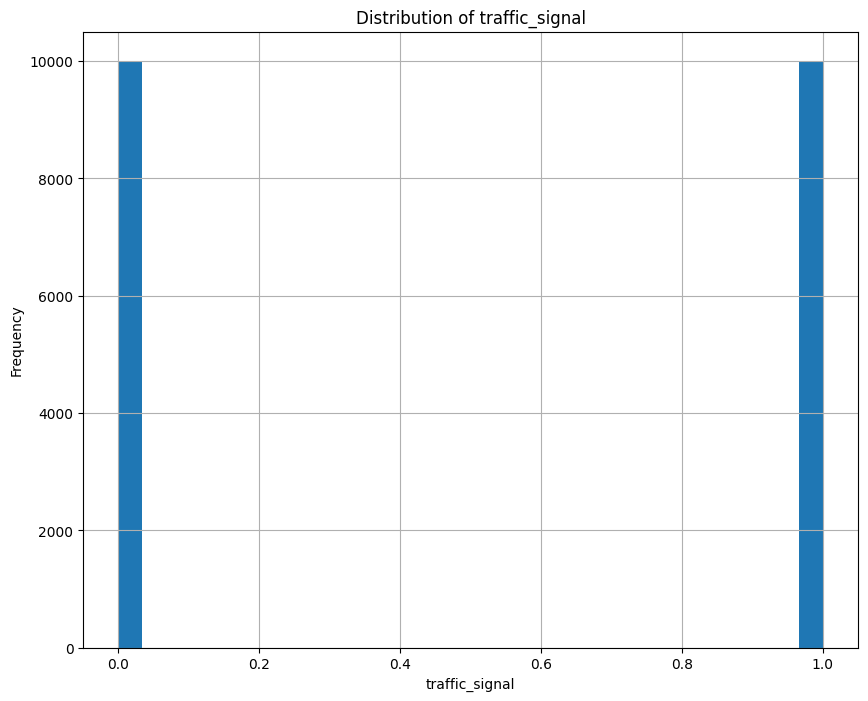

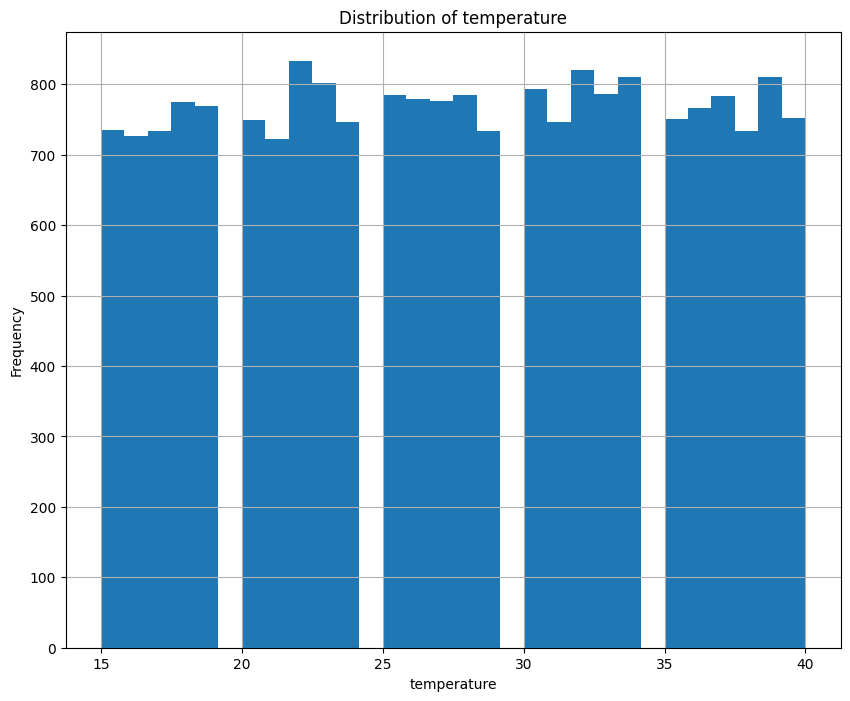

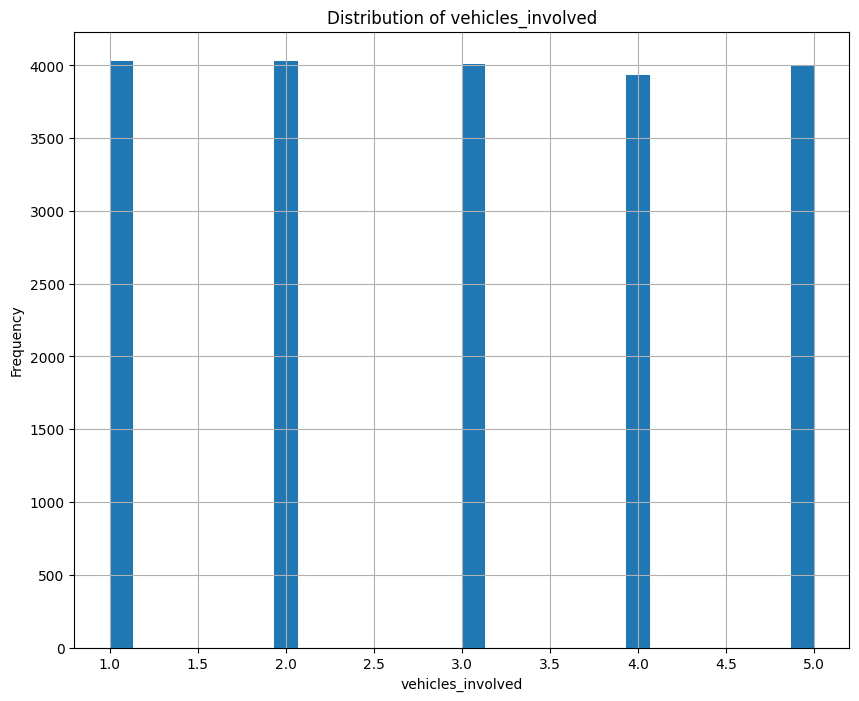

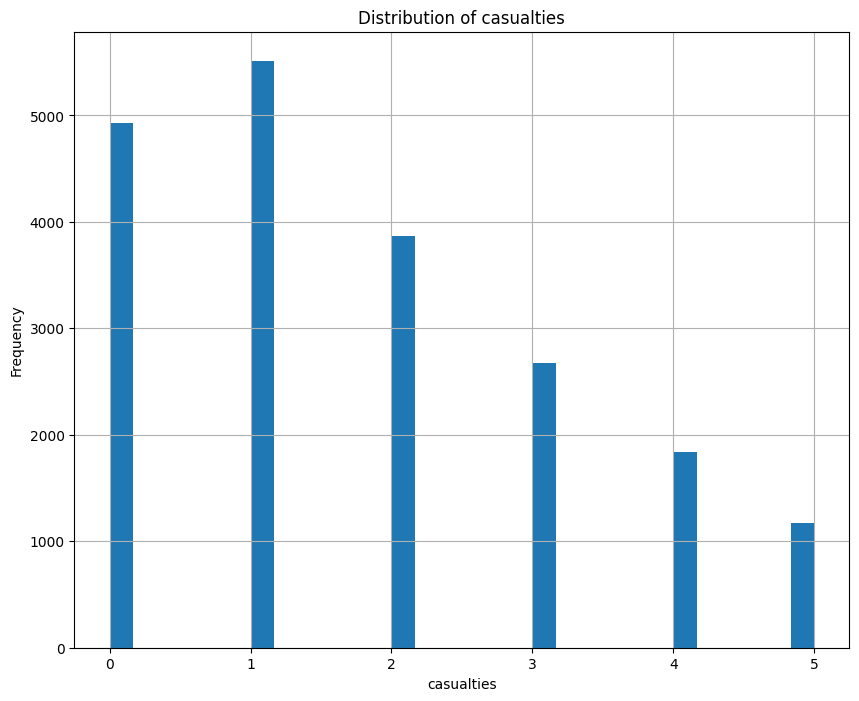

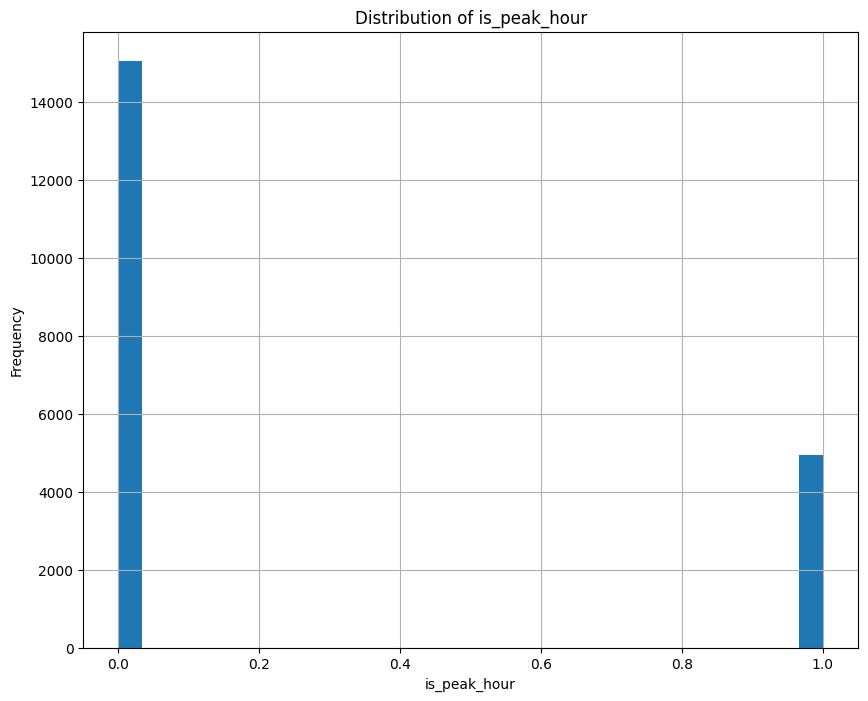

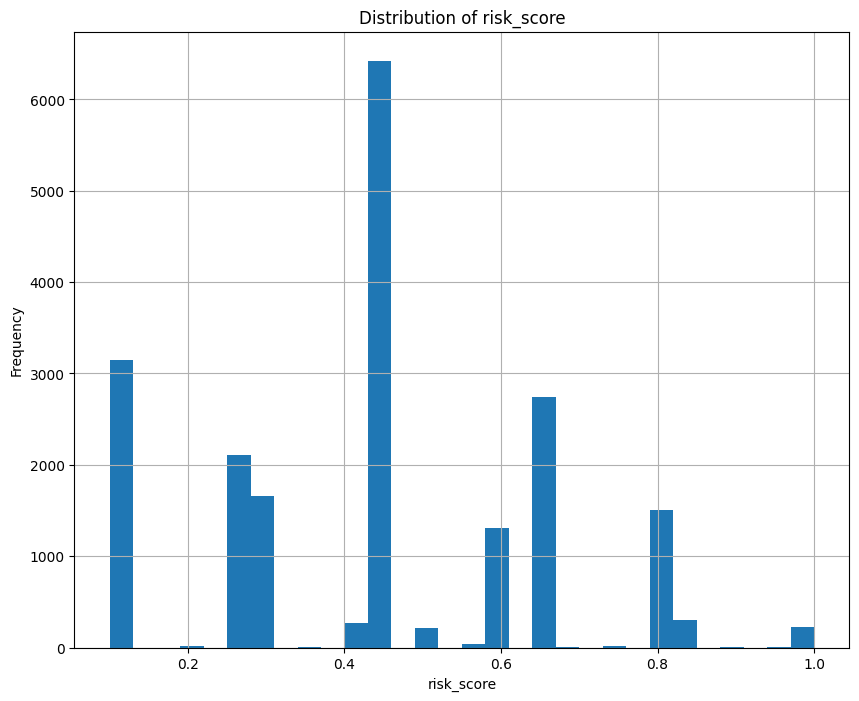

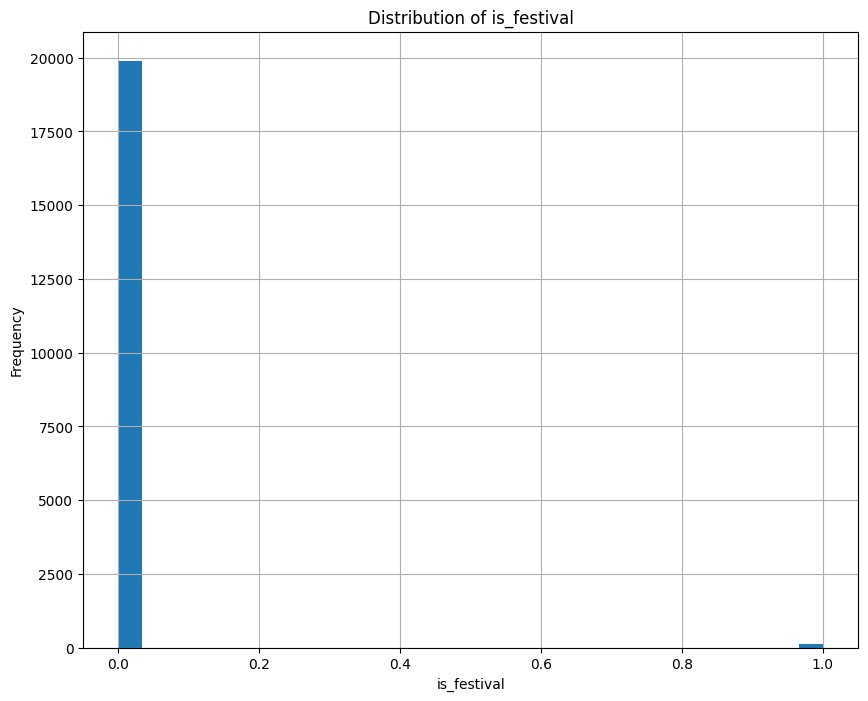

In [35]:
for cols in num_cols:
    plt.figure(figsize=(10,8))
    dataset[cols].hist(bins=30)
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Frequency")
    plt.show()

### Insights from Univariate

* Most accidents happen on weedays not weekends.
* Number of Accidents are high and dominated by 1 Lane, 4 Lane and 5 Lane.
* Least number of casuality count is 5 and maximum count of casualities is atleast 1 or none.
* Maximum number of accidents are not in peak_hours.

In [36]:
dataset[num_cols]

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score,is_festival
0,0,18.680827,73.930388,5,1,3,1,32,2,2,0,0.85,0
1,1,18.817732,72.790846,4,1,4,0,34,4,3,0,0.10,0
2,2,19.096889,72.819424,13,0,3,0,21,1,1,0,0.45,0
3,3,30.787805,76.847507,11,1,1,1,30,5,2,0,0.65,0
4,4,12.965155,80.283313,16,0,3,1,24,2,1,0,0.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,13.092276,77.599571,3,0,1,1,31,3,2,0,0.10,0
19996,19996,13.172928,80.157062,1,1,1,1,20,4,2,0,0.10,0
19997,19997,12.997170,80.150724,15,1,3,0,22,3,3,0,0.10,0
19998,19998,22.454882,88.322213,4,1,3,1,33,1,0,0,0.10,0


In [41]:
state_wise_accidents = dataset.groupby("state")["accident_id"].count().sort_values(ascending=False)

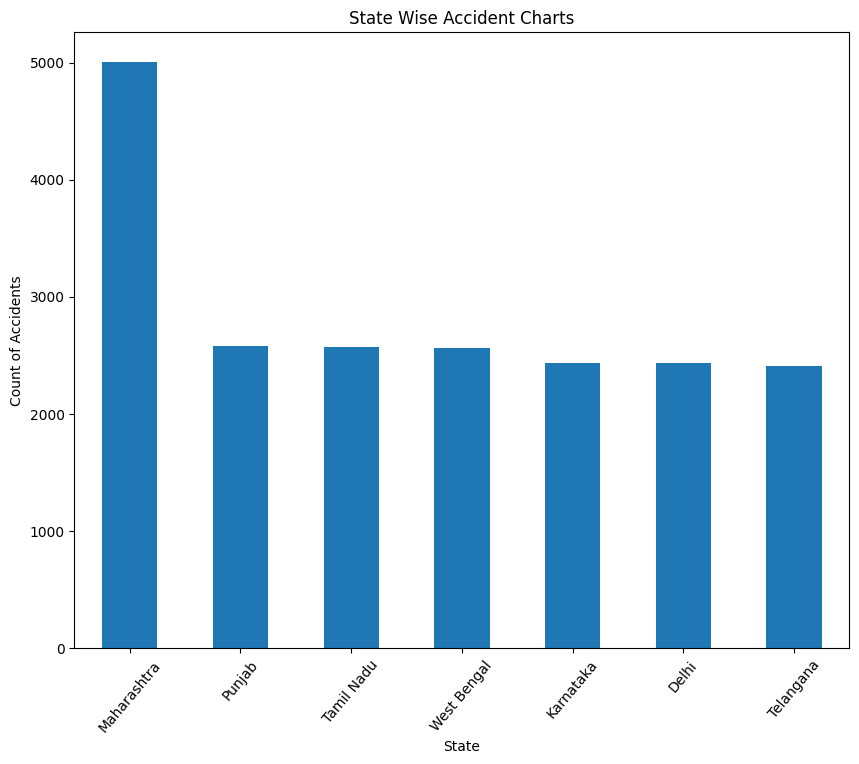

In [42]:
plt.figure(figsize=(10,8))
state_wise_accidents.plot(kind="bar")
plt.title("State Wise Accident Charts")
plt.xlabel("State")
plt.ylabel("Count of Accidents")
plt.xticks(rotation=50)
plt.show()

### Maharashtra has most number of accidents - now this is just a volume observation not a strong insight.

🧠 Why This Can Be Misleading

Maharashtra may have:

More cities 🏙️
More vehicles 🚗
More data points 📊

👉 So obviously count will be high

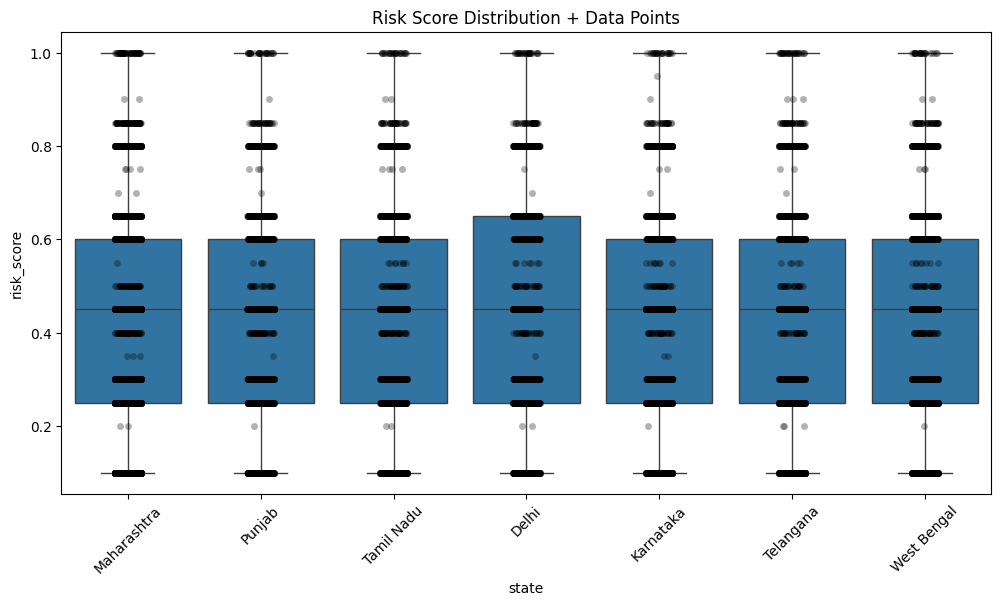

In [47]:
plt.figure(figsize=(12,6))
sns.boxplot(x='state', y='risk_score', data=dataset)
sns.stripplot(x='state', y='risk_score', data=dataset, color='black', alpha=0.3)

plt.xticks(rotation=45)
plt.title("Risk Score Distribution + Data Points")

plt.show()

### Maharashtra
- Median: Relatively high compared to other states.
- Spread: Wide interquartile range (IQR), meaning risk scores vary a lot.
- Outliers: Several high-risk individuals stand out above the whiskers.
- Insight: Maharashtra shows consistently elevated risk with a few extreme cases, suggesting both systemic and individual-level concerns.
Punjab
- Median: Lower than Maharashtra.
- Spread: Moderate, but whiskers extend upward.
- Outliers: Some individuals with unusually high risk.
- Insight: Punjab’s average risk is lower, but variability exists. A few individuals are driving spikes, so interventions may need to target specific high-risk groups.
Tamil Nadu
- Median: Mid-range, not the highest.
- Spread: Narrower box, indicating more consistent scores.
- Outliers: Fewer extreme values.
- Insight: Tamil Nadu’s risk profile is stable and predictable, with fewer surprises. This suggests a more uniform population risk distribution.
Delhi
- Median: Moderate, but slightly skewed upward.
- Spread: Box is relatively tight, but whiskers extend.
- Outliers: Noticeable high-risk individuals.
- Insight: Delhi shows clustered risk around the median, but still has some extreme cases. Most of the population is similar, but outliers need attention.
Karnataka
- Median: Among the higher ones.
- Spread: Narrower box, meaning scores are consistently high.
- Outliers: Few, but the overall level is elevated.
- Insight: Karnataka’s population shows uniformly high risk — not just a few individuals, but a broad trend. This is concerning because it suggests systemic issues.
Telangana
- Median: Moderate.
- Spread: Wide box, lots of variability.
- Outliers: Several scattered points.
- Insight: Telangana is heterogeneous — some individuals are very low-risk, others very high. This uneven distribution suggests mixed conditions across subgroups.

West Bengal
- Median: Lower compared to Karnataka and Maharashtra.
- Spread: Moderate, with whiskers extending.
- Outliers: A few high-risk cases.
- Insight: West Bengal’s risk is generally lower, but variability exists. Most individuals are safe, but outliers highlight pockets of concern.

🧠 Big Picture Takeaways
- High and consistent risk: Karnataka, Maharashtra → systemic issues across the population.
- Moderate but variable risk: Punjab, Telangana, Delhi → targeted interventions needed for outliers.
- Stable and lower risk: Tamil Nadu, West Bengal → relatively safer, but still worth monitoring.


In [50]:
time_based = dataset.groupby("hour")["risk_score"].mean().sort_values(ascending=False)

In [51]:
time_based

hour
18    0.613366
10    0.609569
8     0.608304
17    0.604994
9     0.594911
19    0.591429
5     0.413241
11    0.407967
23    0.402788
7     0.400191
15    0.398397
12    0.397748
14    0.393795
21    0.393494
20    0.391110
13    0.390945
6     0.390304
22    0.383353
16    0.379987
0     0.355833
4     0.355031
1     0.352328
3     0.348119
2     0.341216
Name: risk_score, dtype: float64

In [52]:
def get_time_period(hour):
    if 5<=hour<10:
        return "Morning"
    elif 10<=hour<17:
        return "Day"
    elif 17<=hour<21:
        return "Evening(Peak)"
    else:
        return "Night"

dataset["time_period"] = dataset["hour"].apply(get_time_period)

In [55]:
dataset["time_period"].value_counts()

time_period
Night            6724
Day              5810
Morning          4104
Evening(Peak)    3362
Name: count, dtype: int64

In [56]:
state_time_risk = dataset.groupby(["state", "time_period"])["risk_score"].mean().reset_index()

In [57]:
state_time_risk

,state,time_period,risk_score
0,Delhi,Day,0.426993
1,Delhi,Evening(Peak),0.566418
2,Delhi,Morning,0.473117
3,Delhi,Night,0.363186
4,Karnataka,Day,0.413139
5,Karnataka,Evening(Peak),0.547418
6,Karnataka,Morning,0.489063
7,Karnataka,Night,0.376258
8,Maharashtra,Day,0.427774
9,Maharashtra,Evening(Peak),0.550245


In [60]:
pivot_table = state_time_risk.pivot(index="state", columns="time_period", values="risk_score")

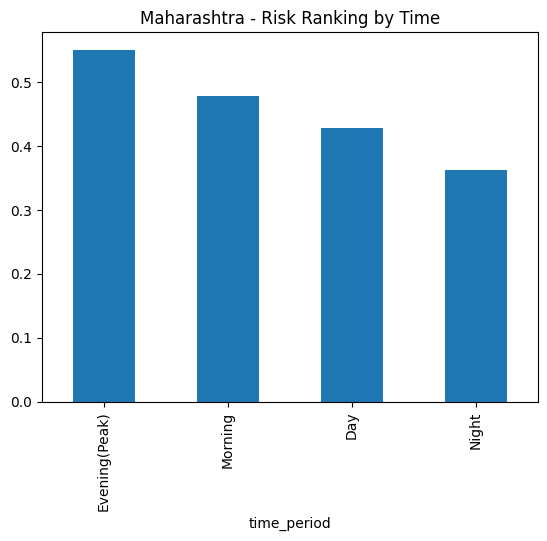

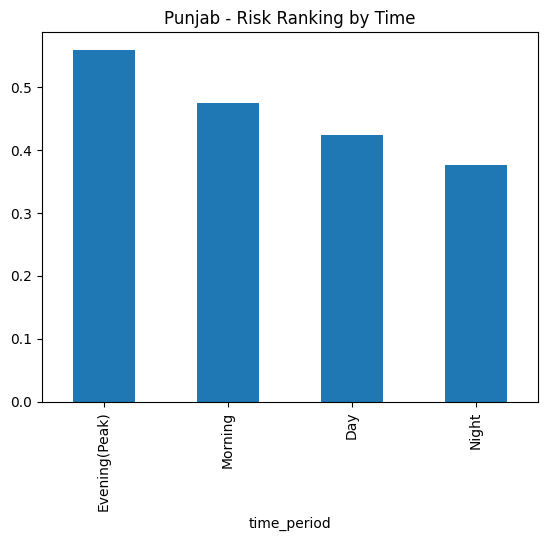

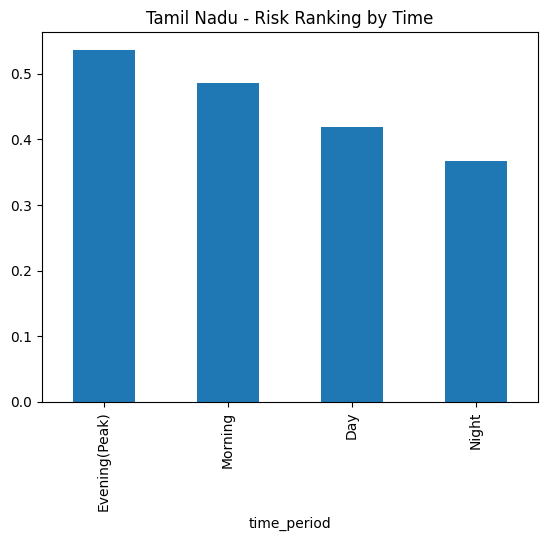

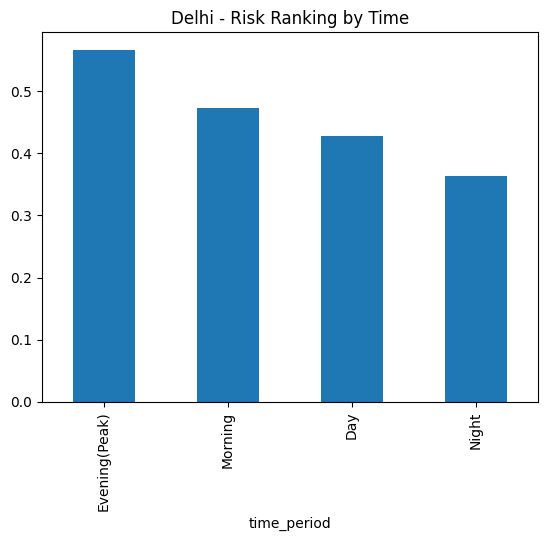

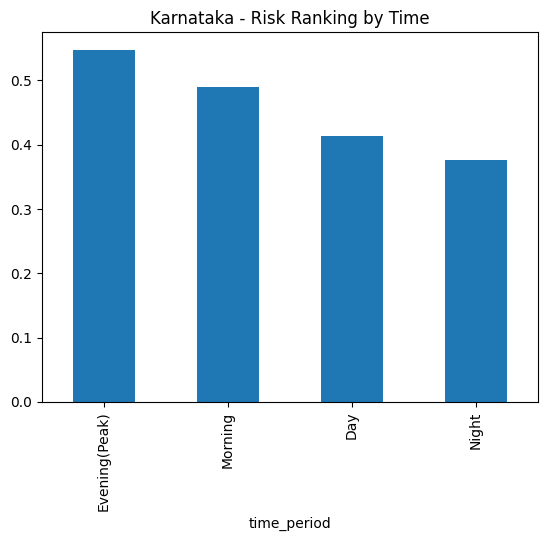

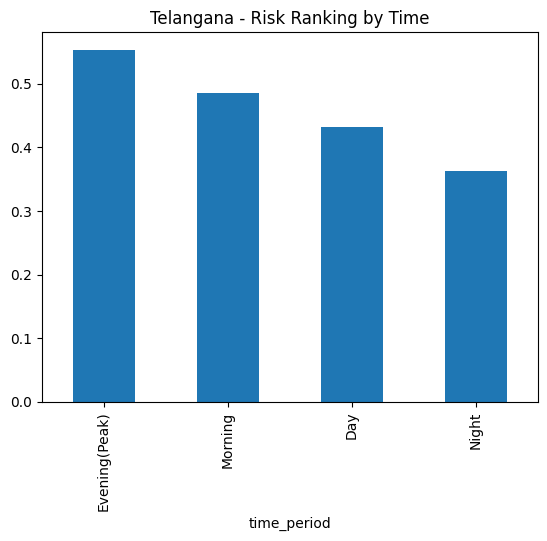

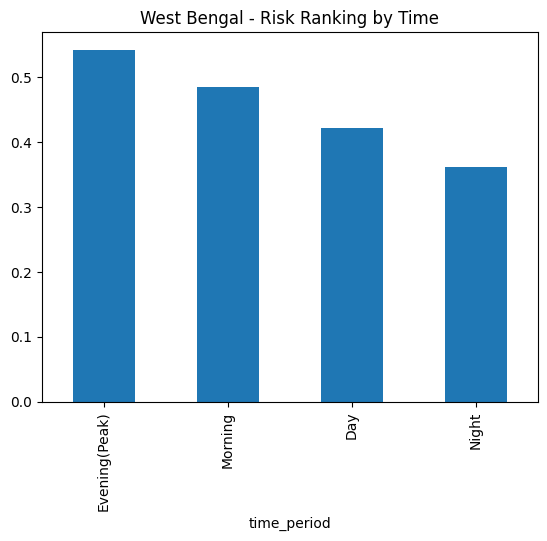

In [64]:
for state in states:
    temp = dataset[dataset['state'] == state]
    temp_group = temp.groupby('time_period')['risk_score'].mean().sort_values(ascending=False)
    
    plt.figure()
    temp_group.plot(kind='bar')
    
    plt.title(f"{state} - Risk Ranking by Time")
    plt.show()

### Above is the Risk Ranking State wise by time zone

* In every state present in above datset Evening is most highly risk ranked time for accidents

In [65]:
dataset

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,is_festival,festival_clean,time_period
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,weather,fatal,2,2,0,NaN,0.85,0,No Festival,Morning
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,weather,major,4,3,0,NaN,0.10,0,No Festival,Night
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,weather,minor,1,1,0,NaN,0.45,0,No Festival,Day
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,distraction,minor,5,2,0,NaN,0.65,0,No Festival,Day
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,distraction,minor,2,1,0,NaN,0.10,0,No Festival,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,distraction,minor,3,2,0,NaN,0.10,0,No Festival,Night
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,distraction,major,4,2,0,NaN,0.10,0,No Festival,Night
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,weather,minor,3,3,0,NaN,0.10,0,No Festival,Day
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,poor road,minor,1,0,0,NaN,0.10,0,No Festival,Night


In [72]:
dataset["cause"].value_counts()

cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

In [73]:
cause_severity = pd.crosstab(dataset["cause"], dataset["accident_severity"])

In [80]:
cause_severity.sort_values(ascending=False, by="fatal")

accident_severity,fatal,major,minor
cause,,,
poor road,623,1172,2179
drunk driving,618,1164,2196
overspeeding,603,1203,2219
weather,601,1205,2191
distraction,542,1244,2240


### Insights

* Poor Road is the cause of most fatal number of accidents.
* Drunk Driving comes second.
* Overspeeding is the thrid and distraction is last

In [82]:
cause_severity_pct = pd.crosstab(
    dataset['cause'],
    dataset['accident_severity'],
    normalize='index'
)

cause_severity_pct.sort_values(by="fatal", ascending=False)

accident_severity,fatal,major,minor
cause,,,
poor road,0.156769,0.294917,0.548314
drunk driving,0.155354,0.292609,0.552036
weather,0.150363,0.301476,0.548161
overspeeding,0.149814,0.298882,0.551304
distraction,0.134625,0.308992,0.556384


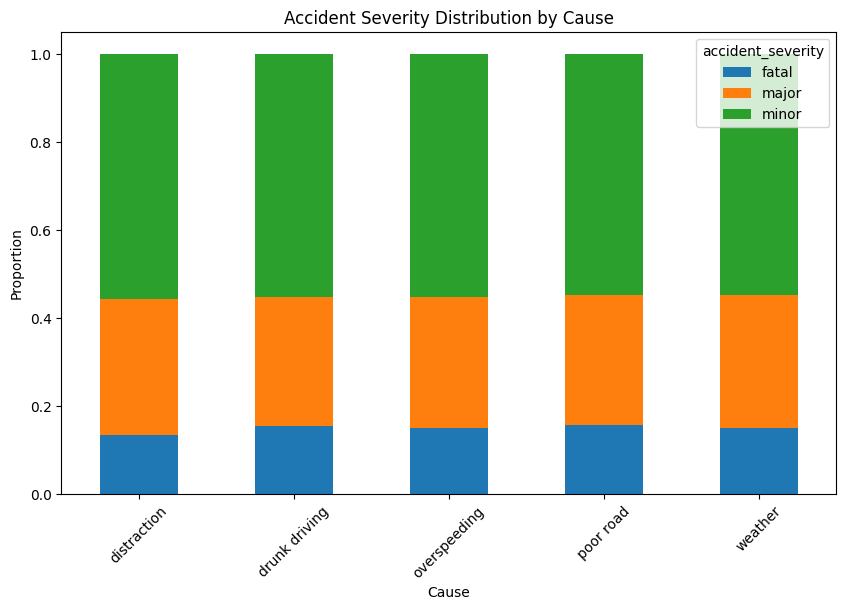

In [83]:
cause_severity_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Accident Severity Distribution by Cause")
plt.xlabel("Cause")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.show()

### “Poor road conditions not only contribute to the highest number of fatal accidents but also have the highest proportion of fatal outcomes, making it the most dangerous cause in terms of severity.”